# Breast Cancer Detection — Minor Project 1
**Dataset:** UCI Breast Cancer Wisconsin | **Task:** Classification


## Problem Statement

Breast cancer is one of the most common cancers. The goal here is to predict if a tumor is **malignant** or **benign** using features extracted from cell images.

I'm using the UCI Breast Cancer Wisconsin dataset which has 569 samples and 30 features.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, auc)


## Load Dataset

In [ ]:
# save dataset to data/
df.to_csv('../data/breast_cancer_wisconsin.csv', index=False)
print("Dataset saved.")

In [2]:
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print(df.shape)
df.head()


(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# quick look at target distribution
df['target'].value_counts()


target
1    357
0    212
Name: count, dtype: int64

In [4]:
df.describe().T.head(10)  # just checking the stats for first few features


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## Data Preprocessing

In [5]:
# check missing values
print("missing:", df.isnull().sum().sum())
print("duplicates:", df.duplicated().sum())


missing: 0
duplicates: 0


In [6]:
# all features are already numeric, no encoding needed
print(df.dtypes.value_counts())


float64    30
int64       1
Name: count, dtype: int64


In [7]:
X = df.drop('target', axis=1)
y = df['target']

# 80-20 split, stratify to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {X_train.shape}, test: {X_test.shape}")


train: (455, 30), test: (114, 30)


In [8]:
# scaling — fit only on train to avoid data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


## EDA

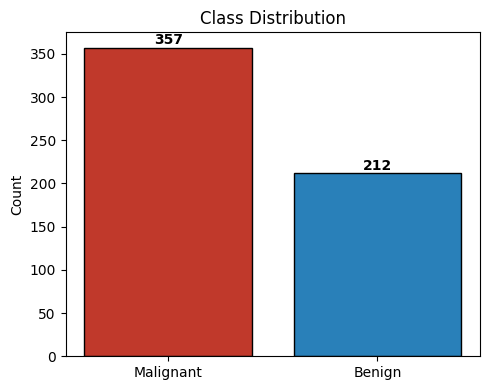

In [9]:
# class distribution plot
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts()
ax.bar(['Malignant', 'Benign'], counts.values, color=['#c0392b', '#2980b9'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


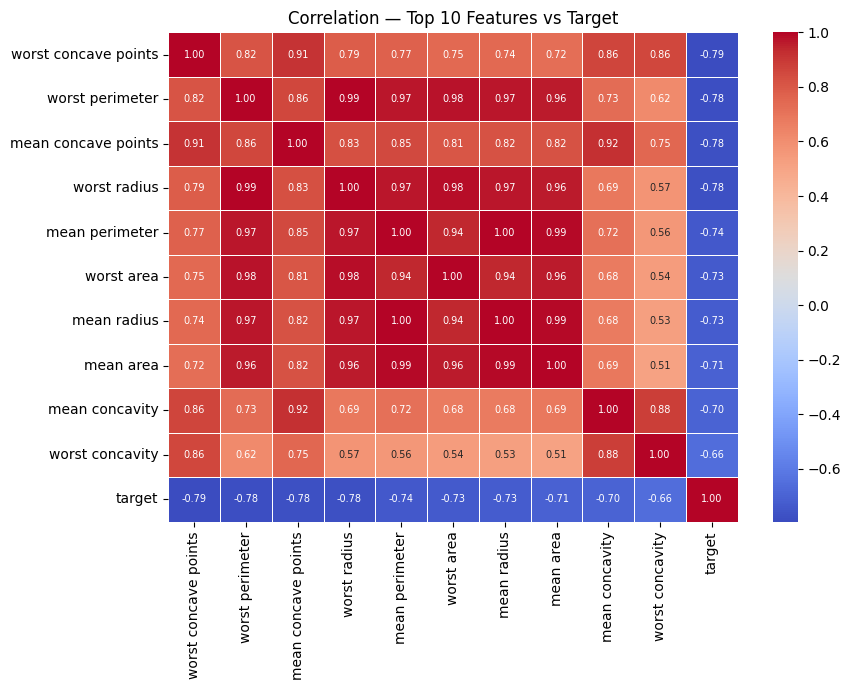

In [10]:
# correlation with target — which features matter most
top_cols = list(df.corr()['target'].abs().sort_values(ascending=False).index[1:11])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[top_cols + ['target']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlation — Top 10 Features vs Target')
plt.tight_layout()
plt.show()

# worst concave points and worst perimeter are most negatively correlated
# so high values = more likely malignant


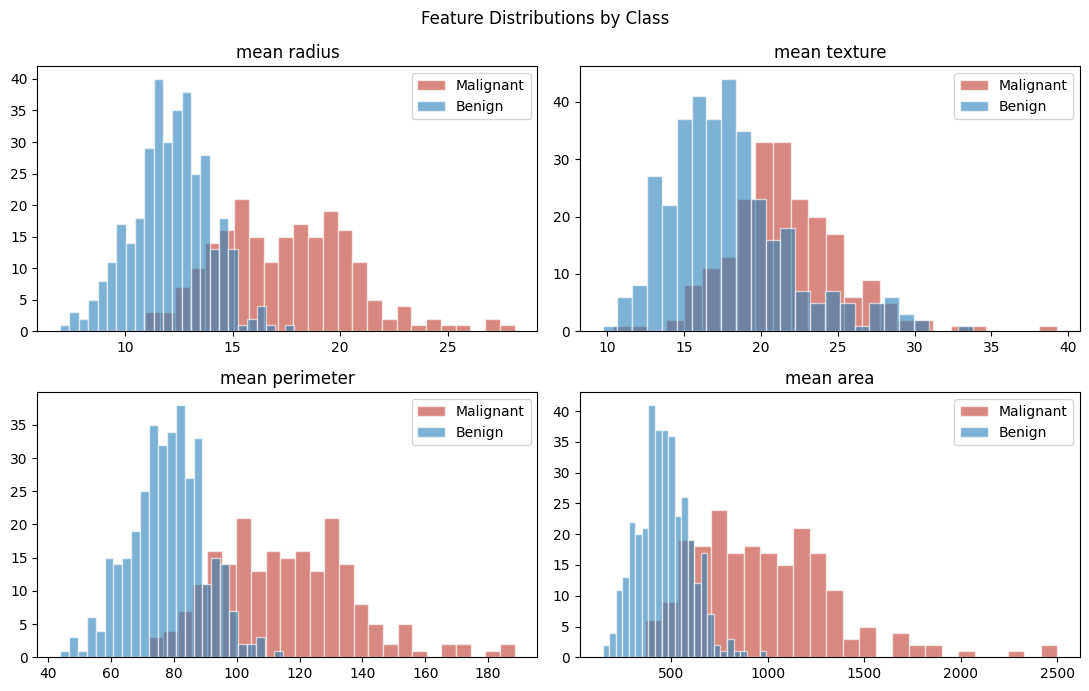

In [11]:
# distribution of key features per class
key_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for i, feat in enumerate(key_feats):
    for label, color, name in [(0, '#c0392b', 'Malignant'), (1, '#2980b9', 'Benign')]:
        axes[i].hist(df[df['target'] == label][feat], alpha=0.6,
                     color=color, bins=25, label=name, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Feature Distributions by Class')
plt.tight_layout()
plt.show()


## Model Training

Training two models to compare:
- **Random Forest** — ensemble method, handles non-linearity well
- **Logistic Regression** — linear baseline, should work well if data is linearly separable (which the correlation matrix hints at)


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
print("RF done")


RF done


In [13]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
print("LR done")


LR done


## Evaluation

In [14]:
y_pred_rf = rf.predict(X_test_s)
y_pred_lr = lr.predict(X_test_s)

results = {}
for name, y_pred in [('Random Forest', y_pred_rf), ('Logistic Regression', y_pred_lr)]:
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4)
    }

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1
Random Forest,0.9561,0.9589,0.9722,0.9655
Logistic Regression,0.9825,0.9861,0.9861,0.9861


In [15]:
# classification reports
for name, y_pred in [('Random Forest', y_pred_rf), ('Logistic Regression', y_pred_lr)]:
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))


--- Random Forest ---
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- Logistic Regression ---
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



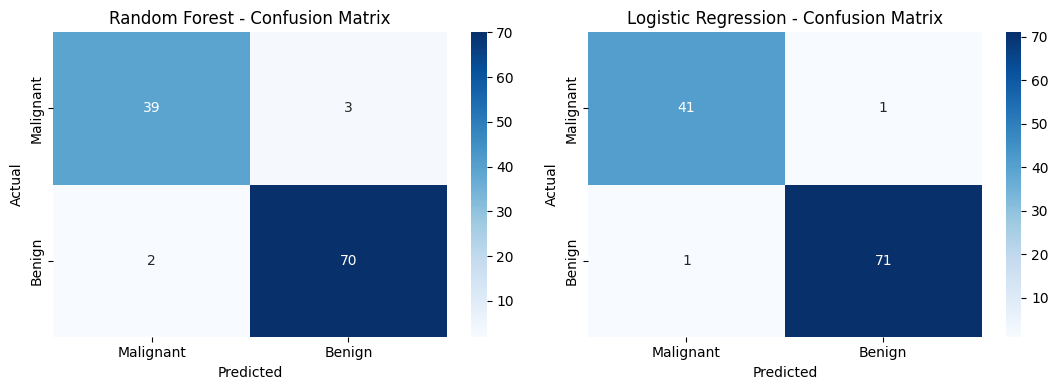

In [16]:
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


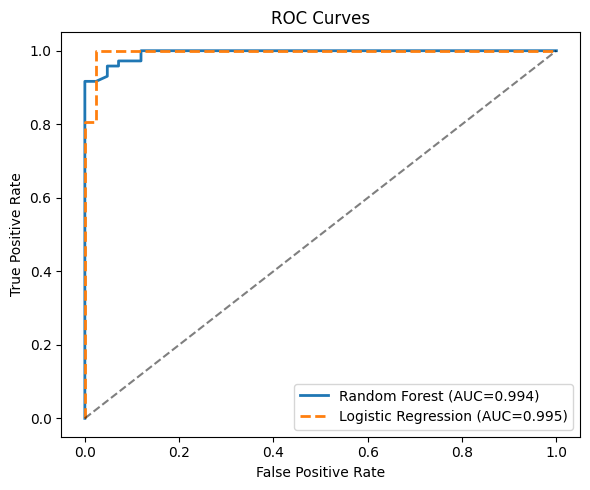

In [17]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, model, style in [('Random Forest', rf, '-'), ('Logistic Regression', lr, '--')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_s)[:, 1])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, linestyle=style, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
plt.tight_layout()
plt.show()


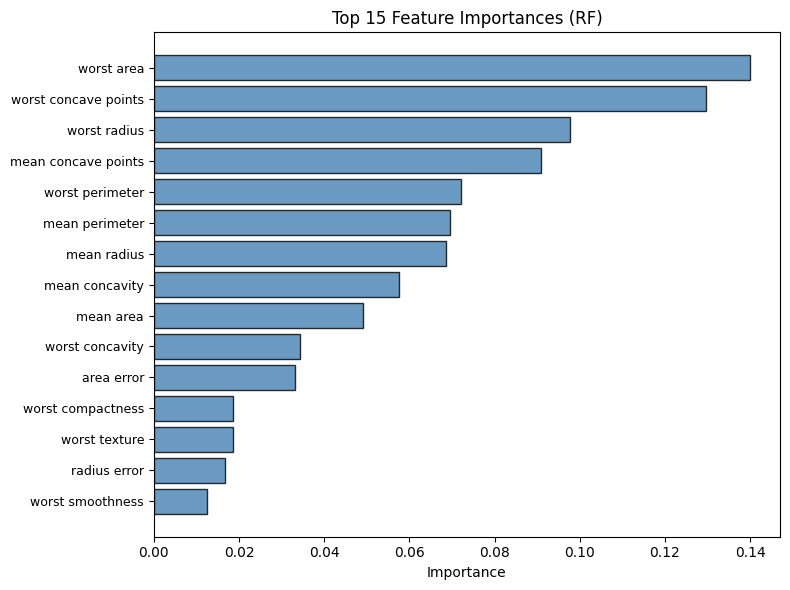

In [18]:
# feature importance from RF
importances = rf.feature_importances_
indices = np.argsort(importances)[-15:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(15), importances[indices], color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels([data.feature_names[i] for i in indices], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances (RF)')
plt.tight_layout()
plt.show()

# 'worst concave points' and 'worst perimeter' are top features
# makes sense — bigger/irregular = more likely malignant


In [19]:
# cross validation to check for overfitting
rf_cv = cross_val_score(rf, X_train_s, y_train, cv=5, scoring='f1')
lr_cv = cross_val_score(lr, X_train_s, y_train, cv=5, scoring='f1')

print(f"RF  5-fold F1: {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")
print(f"LR  5-fold F1: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}")
# low std = stable, not overfitting


RF  5-fold F1: 0.9634 +/- 0.0184
LR  5-fold F1: 0.9843 +/- 0.0101


In [ ]:
import pickle, os
os.makedirs('../model', exist_ok=True)

with open('../model/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../model/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models saved.")

## Conclusion

- Logistic Regression performed better (98.25%) than Random Forest (95.61%)
- This makes sense because the data seems to be mostly linearly separable based on EDA
- Both models have AUC > 0.99 which is really good
- No significant overfitting — CV scores are consistent with test scores

**Best model: Logistic Regression** with F1 = 0.9861

For future work:
- Try hyperparameter tuning with GridSearchCV
- Try SVM or XGBoost
- Use SHAP for better model explainability

**Dataset source:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
